# Reference based annotation of cells 



In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scgeo as sg


In [2]:


adata = sc.read_h5ad("data/ref/5521512/ref.h5ad")

print(adata)
print(adata.obs.columns)
print(adata.obsm.keys())

AnnData object with n_obs × n_vars = 297627 × 3000
    obs: 'celltype.l2', 'celltype.l1', 'ori.index', 'nCount_refAssay', 'nFeature_refAssay', 'ident'
    uns: 'X_name'
    obsm: 'REFDR', 'REFUMAP'
Index(['celltype.l2', 'celltype.l1', 'ori.index', 'nCount_refAssay',
       'nFeature_refAssay', 'ident'],
      dtype='object')
KeysView(AxisArrays with keys: REFDR, REFUMAP)


In [3]:

adata.obsm["X_umap"] = np.asarray(adata.obsm["REFUMAP"])
adata.obsm["X_ref"] = np.asarray(adata.obsm["REFDR"])

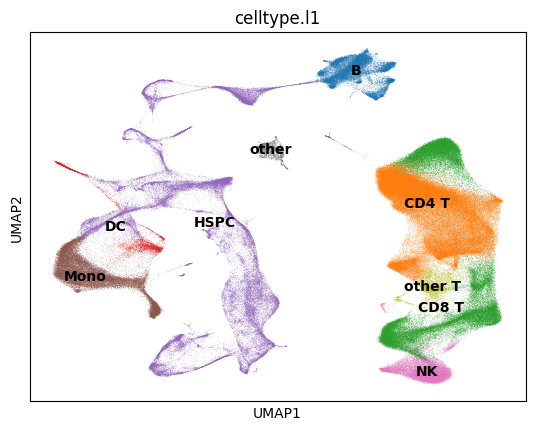

In [4]:
sc.pl.umap(adata, color='celltype.l1',legend_loc='on data')

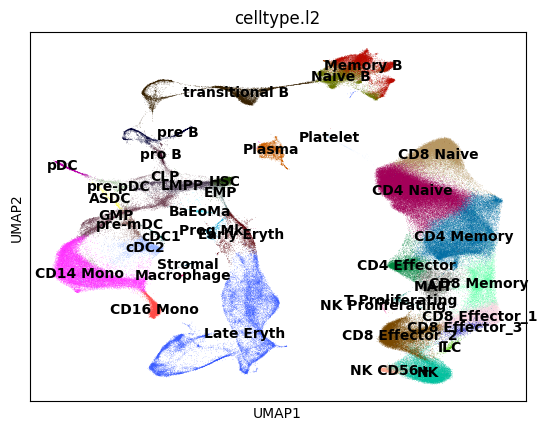

In [5]:
sc.pl.umap(adata, color='celltype.l2',legend_loc='on data')

In [6]:

del adata.obsm["REFUMAP"]
del adata.obsm["REFDR"]

adata.write("data/ref/5521512/ref_clean.h5ad")

In [7]:
adata=sc.read_h5ad("data/GSE280305_for_Ref.h5ad")

In [8]:
pd.crosstab(
    adata.obs["leiden_raw"],
    adata.obs["scgeo_pred"],
    normalize="index",
)

scgeo_pred,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
leiden_raw,,,,,,,,,,,,,,,,
0,0.998657,0.000959,0.000000,0.000000,0.000192,0.000000,0.000000,0.000000,0.000192,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.002550,0.995154,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002295,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.893078,0.006194,0.007272,0.088877,0.000000,0.000000,0.000000,0.003232,0.000000,0.000269,0.000000,0.000808,0.000269,0.000000
3,0.000000,0.000000,0.011435,0.177530,0.000858,0.806461,0.000000,0.000286,0.000000,0.002573,0.000000,0.000572,0.000000,0.000000,0.000286,0.000000
4,0.013527,0.001932,0.012560,0.000000,0.967794,0.002899,0.000000,0.000000,0.000644,0.000322,0.000000,0.000322,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000348,0.000000,0.000000,0.993046,0.000000,0.000000,0.004868,0.000695,0.000000,0.000000,0.001043,0.000000,0.000000,0.000000
6,0.915341,0.030272,0.000000,0.000000,0.014879,0.000000,0.030272,0.000000,0.001026,0.000000,0.008209,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996115,0.000000,0.000000,0.000000,0.003885,0.000000,0.000000,0.000000,0.000000
8,0.001791,0.017313,0.002388,0.000000,0.003582,0.000597,0.000000,0.000000,0.952836,0.016716,0.000000,0.003582,0.001194,0.000000,0.000000,0.000000


In [9]:
adata.obs.groupby("leiden_raw")[["scgeo_conf", "scgeo_ood"]].mean().sort_values("scgeo_ood", ascending=False)

/tmp/ipykernel_6216/1381089137.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("leiden_raw")[["scgeo_conf", "scgeo_ood"]].mean().sort_values("scgeo_ood", ascending=False)


,scgeo_conf,scgeo_ood
leiden_raw,,
15,0.694145,0.918825
11,0.836224,0.716321
9,0.885578,0.702898
3,0.657760,0.682884
4,0.929777,0.657934
2,0.862980,0.657437
10,0.843786,0.609982
8,0.929202,0.549889
5,0.969304,0.548251


In [10]:
pd.crosstab(
    adata.obs["leiden_raw"],
    adata.obs["timepoint"],
    normalize="index"
)

timepoint,D8,D11,D14,D21
leiden_raw,,,,
0,0.951266,0.001919,0.037222,0.009593
1,0.918388,0.006631,0.013262,0.061719
2,0.136009,0.047670,0.434420,0.381901
3,0.021727,0.084620,0.050600,0.843053
4,0.303060,0.090177,0.222544,0.384219
5,0.209318,0.442629,0.317803,0.030250
6,0.030272,0.658799,0.035916,0.275013
7,0.231410,0.413984,0.269145,0.085461
8,0.469254,0.069254,0.159403,0.302090


In [11]:

cluster_pred = (
    pd.crosstab(
        adata.obs["leiden_raw"].astype(str),
        adata.obs["scgeo_pred"].astype(str),
        normalize="index",
    )
)

dominant_pred = cluster_pred.idxmax(axis=1)
dominant_pred_frac = cluster_pred.max(axis=1)

cluster_metrics = (
    adata.obs.groupby("leiden_raw", observed=True)
    .agg(
        mean_conf=("scgeo_conf", "mean"),
        mean_ood=("scgeo_ood", "mean"),
        n_cells=("scgeo_ood", "size"),
    )
)

cluster_align = pd.crosstab(
    adata.obs["leiden_raw"].astype(str),
    adata.obs["alignment_group"].astype(str),
    normalize="index",
)
dominant_align = cluster_align.idxmax(axis=1)
dominant_align_frac = cluster_align.max(axis=1)

cluster_time = pd.crosstab(
    adata.obs["leiden_raw"].astype(str),
    adata.obs["timepoint"].astype(str),
    normalize="index",
)

dominant_time = cluster_time.idxmax(axis=1)
dominant_time_frac = cluster_time.max(axis=1)

cluster_summary = pd.DataFrame({
    "dominant_pred": dominant_pred,
    "dominant_pred_frac": dominant_pred_frac,
    "dominant_align": dominant_align,
    "dominant_align_frac": dominant_align_frac,
    "dominant_time": dominant_time,
    "dominant_time_frac": dominant_time_frac,
}).join(cluster_metrics)

cluster_summary = cluster_summary.sort_values("mean_ood", ascending=False)
cluster_summary

,dominant_pred,dominant_pred_frac,dominant_align,dominant_align_frac,dominant_time,dominant_time_frac,mean_conf,mean_ood,n_cells
leiden_raw,,,,,,,,,
15,15,0.505226,discordant,1.0,D8,0.299652,0.694145,0.918825,287
11,11,0.562130,discordant,1.0,D14,0.459566,0.836224,0.716321,507
9,9,0.931034,discordant,1.0,D14,0.484401,0.885578,0.702898,1218
3,5,0.806461,aligned,1.0,D21,0.843053,0.657760,0.682884,3498
4,4,0.967794,discordant,1.0,D21,0.384219,0.929777,0.657934,3105
2,2,0.893078,aligned,1.0,D14,0.434420,0.862980,0.657437,3713
10,10,0.366255,discordant,1.0,D21,0.729767,0.843786,0.609982,729
8,8,0.952836,aligned,1.0,D8,0.469254,0.929202,0.549889,1675
5,5,0.993046,other,1.0,D11,0.442629,0.969304,0.548251,2876


In [12]:
cluster_summary["interpretation_hint"] = np.select(
    [
        (cluster_summary["mean_ood"] > 0.8) & (cluster_summary["mean_conf"] < 0.8),
        (cluster_summary["dominant_align"] == "discordant"),
        (cluster_summary["dominant_pred_frac"] > 0.9) & (cluster_summary["mean_ood"] < 0.4),
    ],
    [
        "highly divergent / perturbed",
        "trajectory-discordant",
        "stable reference-like",
    ],
    default="intermediate / mixed",
)

cluster_summary

,dominant_pred,dominant_pred_frac,dominant_align,dominant_align_frac,dominant_time,dominant_time_frac,mean_conf,mean_ood,n_cells,interpretation_hint
leiden_raw,,,,,,,,,,
15,15,0.505226,discordant,1.0,D8,0.299652,0.694145,0.918825,287,highly divergent / perturbed
11,11,0.562130,discordant,1.0,D14,0.459566,0.836224,0.716321,507,trajectory-discordant
9,9,0.931034,discordant,1.0,D14,0.484401,0.885578,0.702898,1218,trajectory-discordant
3,5,0.806461,aligned,1.0,D21,0.843053,0.657760,0.682884,3498,intermediate / mixed
4,4,0.967794,discordant,1.0,D21,0.384219,0.929777,0.657934,3105,trajectory-discordant
2,2,0.893078,aligned,1.0,D14,0.434420,0.862980,0.657437,3713,intermediate / mixed
10,10,0.366255,discordant,1.0,D21,0.729767,0.843786,0.609982,729,trajectory-discordant
8,8,0.952836,aligned,1.0,D8,0.469254,0.929202,0.549889,1675,intermediate / mixed
5,5,0.993046,other,1.0,D11,0.442629,0.969304,0.548251,2876,intermediate / mixed


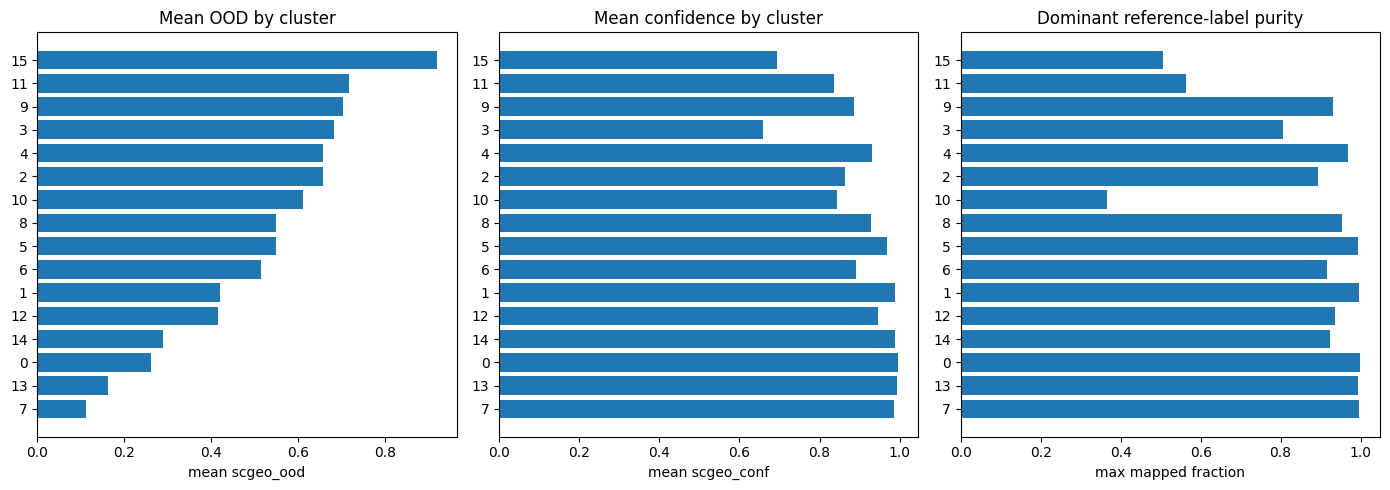

In [13]:
import matplotlib.pyplot as plt

plot_df = cluster_summary.copy()
plot_df["cluster"] = plot_df.index.astype(str)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# A. mean OOD
axes[0].barh(plot_df["cluster"], plot_df["mean_ood"])
axes[0].invert_yaxis()
axes[0].set_title("Mean OOD by cluster")
axes[0].set_xlabel("mean scgeo_ood")

# B. mean confidence
axes[1].barh(plot_df["cluster"], plot_df["mean_conf"])
axes[1].invert_yaxis()
axes[1].set_title("Mean confidence by cluster")
axes[1].set_xlabel("mean scgeo_conf")

# C. dominant reference mapping purity
axes[2].barh(plot_df["cluster"], plot_df["dominant_pred_frac"])
axes[2].invert_yaxis()
axes[2].set_title("Dominant reference-label purity")
axes[2].set_xlabel("max mapped fraction")

plt.tight_layout()
plt.show()

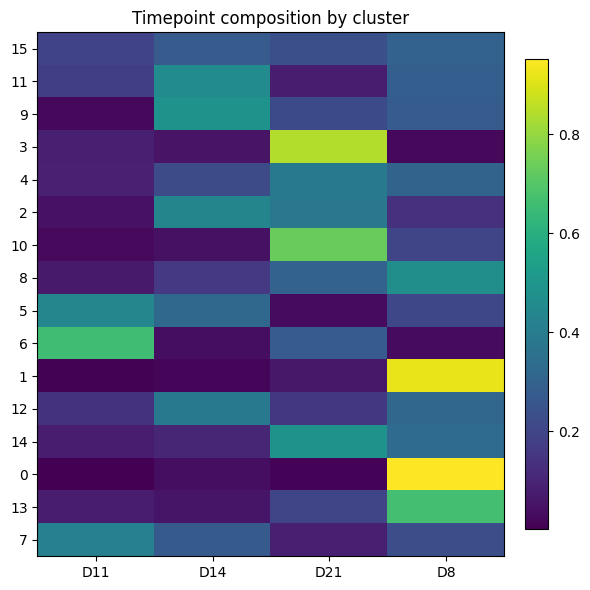

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cluster_time.loc[plot_df.index].to_numpy(), aspect="auto")

ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_df.index.astype(str))
ax.set_xticks(range(cluster_time.shape[1]))
ax.set_xticklabels(cluster_time.columns.astype(str))
ax.set_title("Timepoint composition by cluster")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

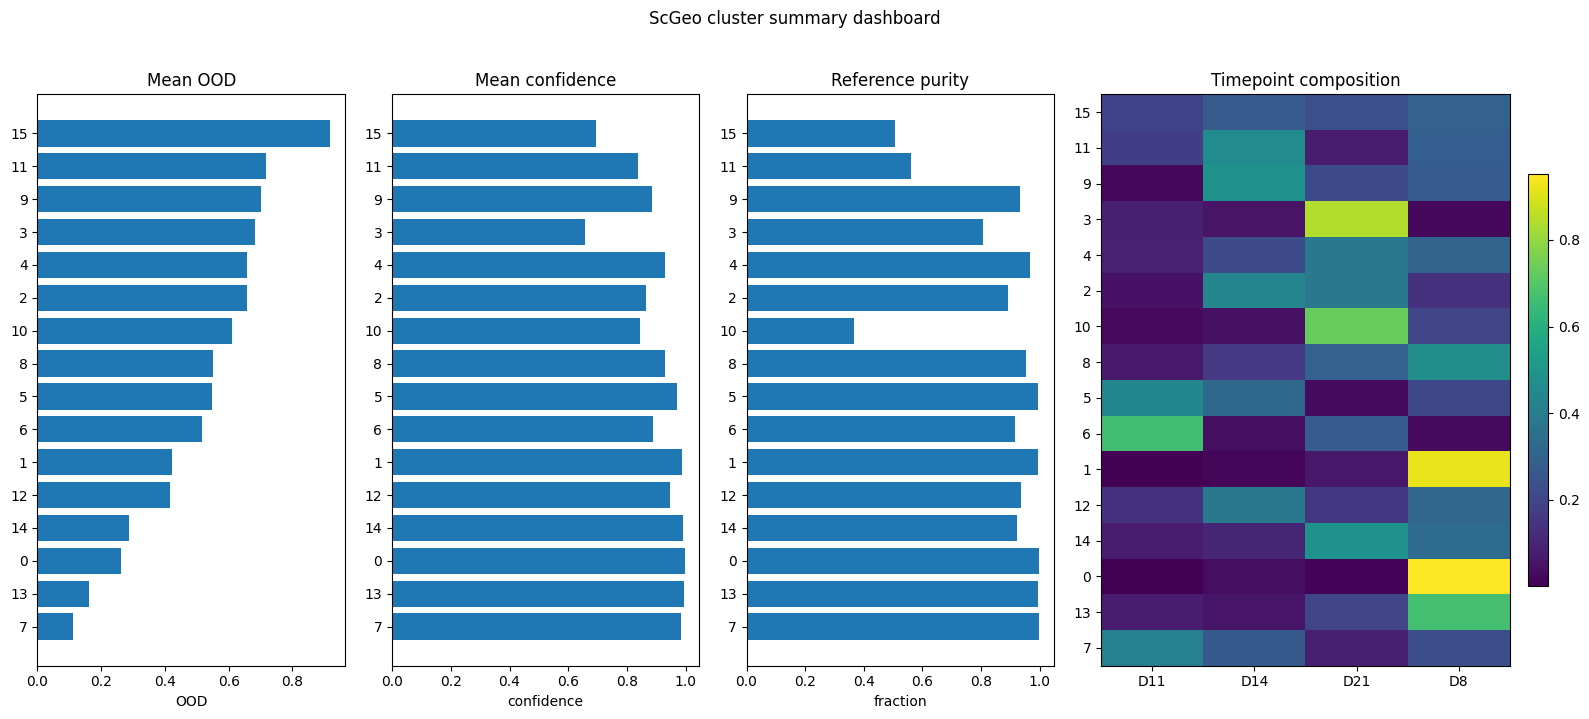

In [15]:
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(1, 4, width_ratios=[1.1, 1.1, 1.1, 1.6])

ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(plot_df["cluster"], plot_df["mean_ood"])
ax1.invert_yaxis()
ax1.set_title("Mean OOD")
ax1.set_xlabel("OOD")

ax2 = fig.add_subplot(gs[0, 1])
ax2.barh(plot_df["cluster"], plot_df["mean_conf"])
ax2.invert_yaxis()
ax2.set_title("Mean confidence")
ax2.set_xlabel("confidence")

ax3 = fig.add_subplot(gs[0, 2])
ax3.barh(plot_df["cluster"], plot_df["dominant_pred_frac"])
ax3.invert_yaxis()
ax3.set_title("Reference purity")
ax3.set_xlabel("fraction")

ax4 = fig.add_subplot(gs[0, 3])
im = ax4.imshow(cluster_time.loc[plot_df.index].to_numpy(), aspect="auto")
ax4.set_yticks(range(len(plot_df.index)))
ax4.set_yticklabels(plot_df.index.astype(str))
ax4.set_xticks(range(cluster_time.shape[1]))
ax4.set_xticklabels(cluster_time.columns.astype(str))
ax4.set_title("Timepoint composition")
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

fig.suptitle("ScGeo cluster summary dashboard", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden_raw",
    method="wilcoxon",
    use_raw=False,
    pts=True,
)

/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/mnt/d/scgeo/.venv/lib/python3.12/site-p

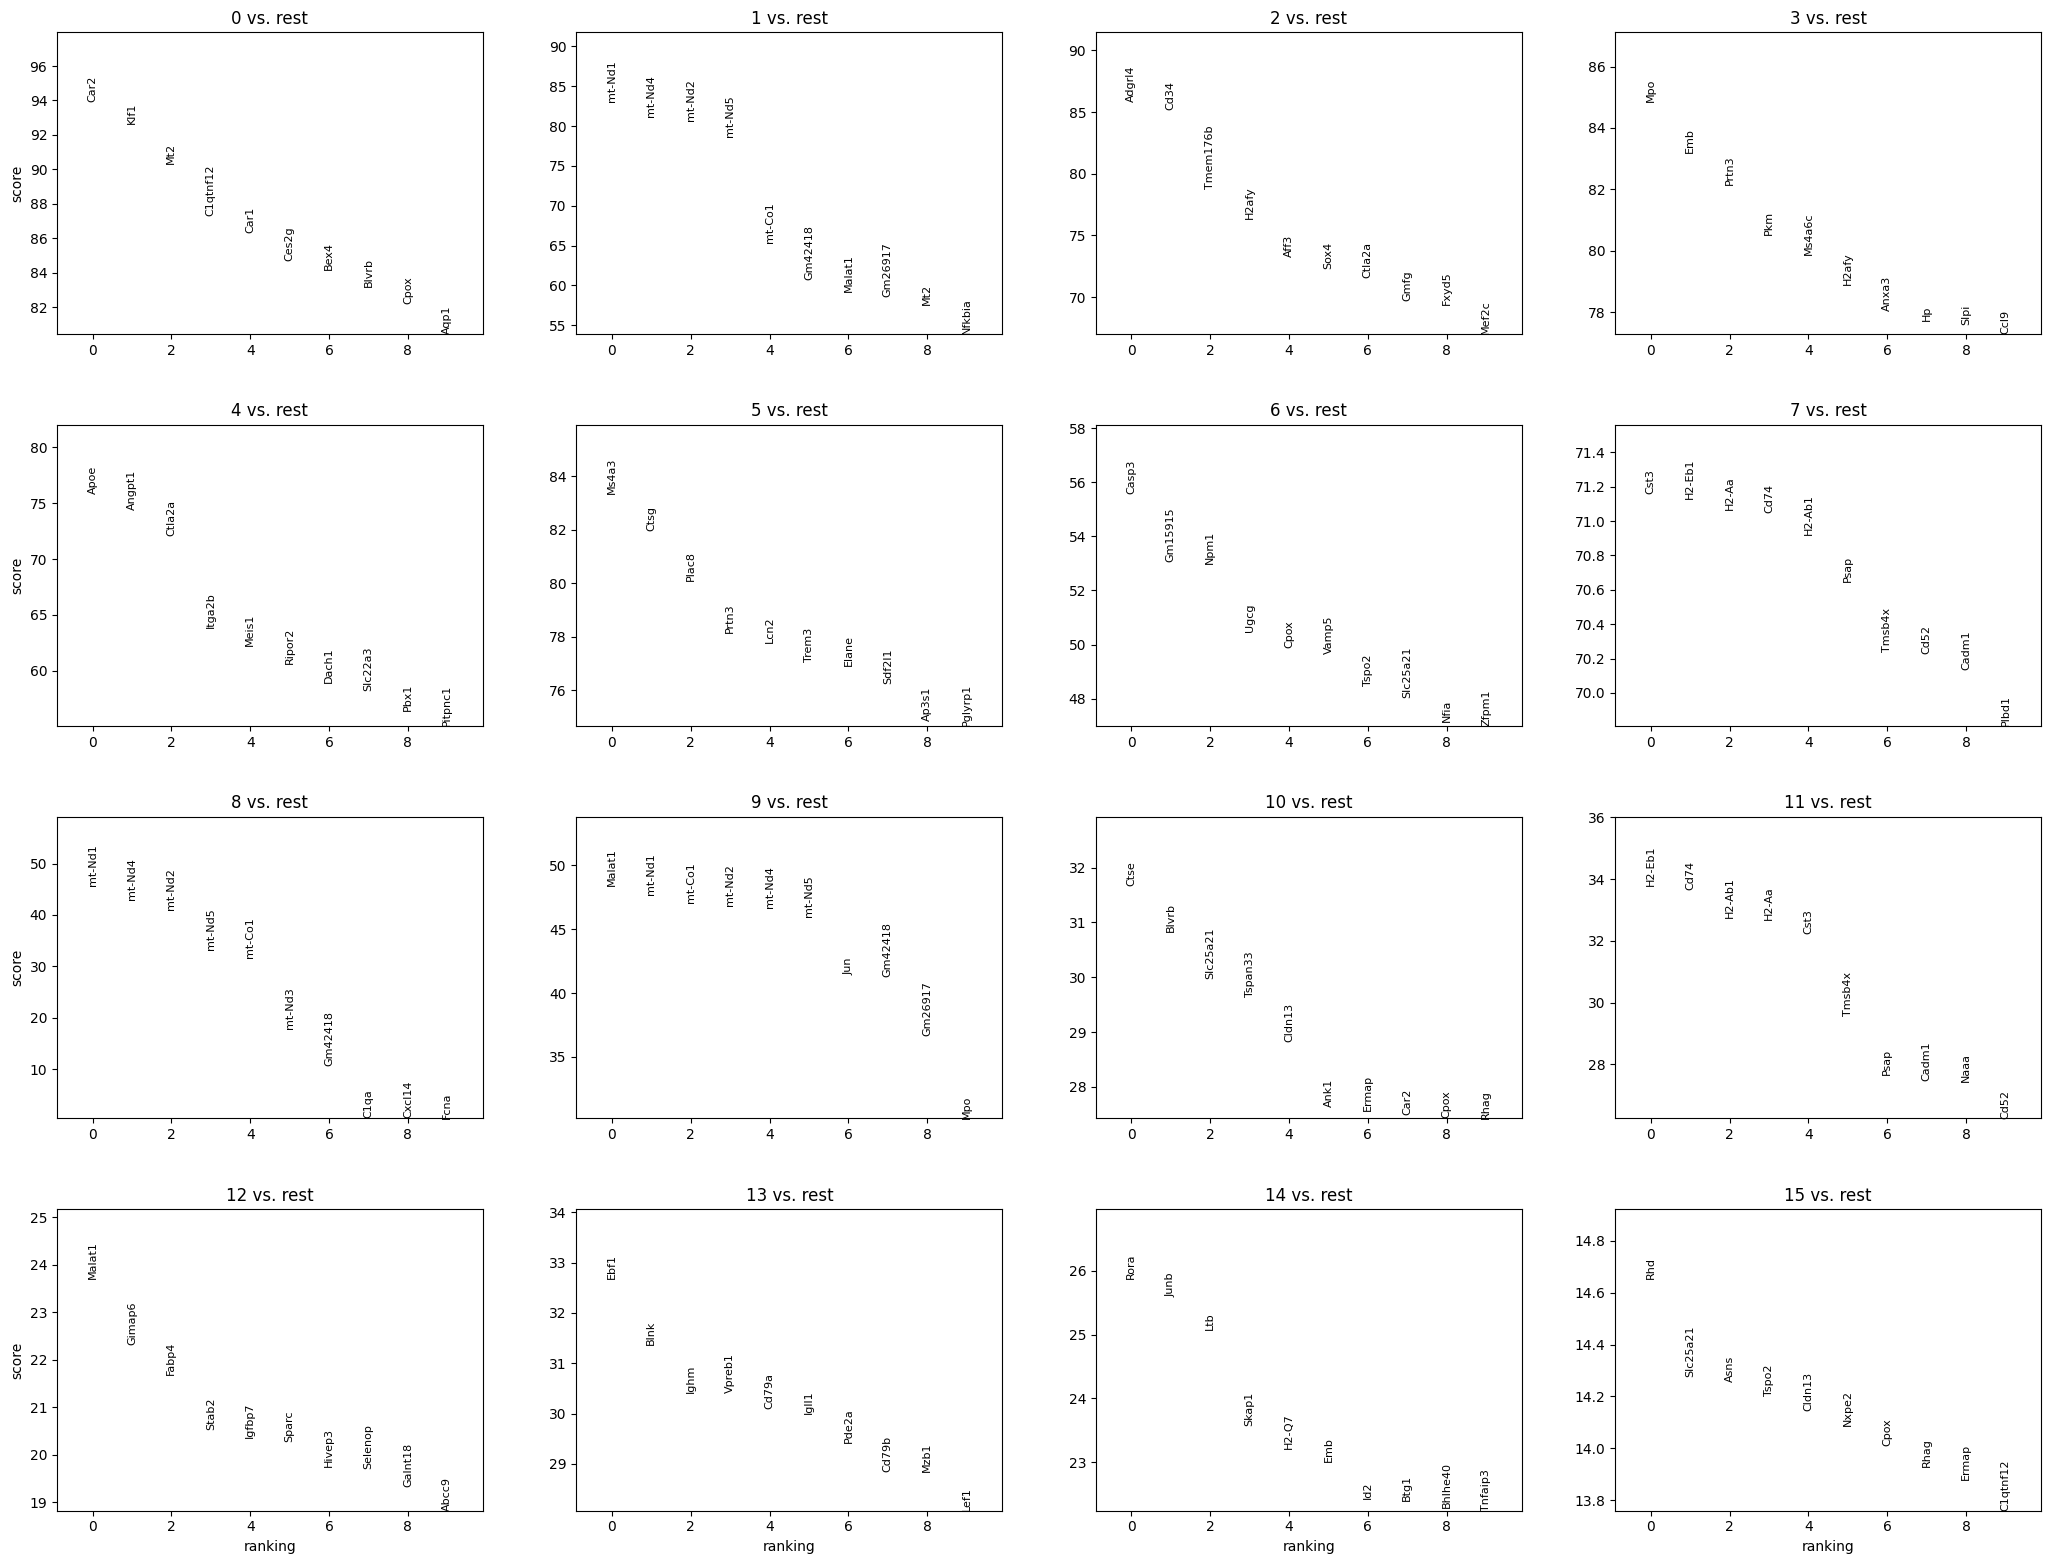

In [17]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False,
)

In [18]:
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,Car2,93.914757,NaN,0.0,0.0,1.0,1.0
1,0,Klf1,92.649185,NaN,0.0,0.0,1.0,1.0
2,0,Mt2,90.324738,NaN,0.0,0.0,1.0,1.0
3,0,C1qtnf12,87.278137,NaN,0.0,0.0,1.0,1.0
4,0,Car1,86.319481,NaN,0.0,0.0,1.0,1.0


In [19]:
interesting = ["15", "11", "10", "3", "9", "0", "7"]

In [20]:
for cl in interesting:
    print(f"\n=== Cluster {cl} ===")
    display(markers[markers["group"] == cl].head(20))


=== Cluster 15 ===


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
45000,15,Rhd,14.654315,NaN,1.264252e-48,3.792757e-45,1.0,1.0
45001,15,Slc25a21,14.275281,NaN,3.120268e-46,4.070563e-43,1.0,1.0
45002,15,Asns,14.256736,NaN,4.070563e-46,4.070563e-43,1.0,1.0
45003,15,Tspo2,14.203253,NaN,8.745723e-46,6.559292e-43,1.0,1.0
45004,15,Cldn13,14.143296,NaN,2.054320e-45,1.232592e-42,1.0,1.0
45005,15,Nxpe2,14.087103,NaN,4.558821e-45,2.279410e-42,1.0,1.0
45006,15,Cpox,14.006739,NaN,1.417665e-44,6.075709e-42,1.0,1.0
45007,15,Rhag,13.927805,NaN,4.293500e-44,1.610063e-41,1.0,1.0
45008,15,Ermap,13.875664,NaN,8.896541e-44,2.965514e-41,1.0,1.0
45009,15,C1qtnf12,13.758774,NaN,4.511137e-43,1.353341e-40,1.0,1.0



=== Cluster 11 ===


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
33000,11,H2-Eb1,33.766945,NaN,6.030399e-250,1.809120e-246,1.0,1.0
33001,11,Cd74,33.657379,NaN,2.431708e-248,3.647561e-245,1.0,1.0
33002,11,H2-Ab1,32.758743,NaN,2.279612e-235,2.279612e-232,1.0,1.0
33003,11,H2-Aa,32.666813,NaN,4.625073e-234,3.468805e-231,1.0,1.0
33004,11,Cst3,32.233208,NaN,6.048380e-228,3.629028e-225,1.0,1.0
33005,11,Tmsb4x,29.555878,NaN,5.518877e-192,2.759438e-189,1.0,1.0
33006,11,Psap,27.659435,NaN,2.149115e-168,9.210493e-166,1.0,1.0
33007,11,Cadm1,27.446339,NaN,7.683016e-166,2.881131e-163,1.0,1.0
33008,11,Naaa,27.415396,NaN,1.797382e-165,5.991275e-163,1.0,1.0
33009,11,Cd52,26.245756,NaN,7.991273e-152,2.397382e-149,1.0,1.0



=== Cluster 10 ===


...

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
27000,9,Malat1,48.351006,NaN,0.000000e+00,0.000000e+00,1.0,1.0
27001,9,mt-Nd1,47.651360,NaN,0.000000e+00,0.000000e+00,1.0,1.0
27002,9,mt-Co1,47.045918,NaN,0.000000e+00,0.000000e+00,1.0,1.0
27003,9,mt-Nd2,46.836937,NaN,0.000000e+00,0.000000e+00,1.0,1.0
27004,9,mt-Nd4,46.624805,NaN,0.000000e+00,0.000000e+00,1.0,1.0
27005,9,mt-Nd5,45.956921,NaN,0.000000e+00,0.000000e+00,1.0,1.0
27006,9,Jun,41.425621,NaN,0.000000e+00,0.000000e+00,1.0,1.0
27007,9,Gm42418,41.247093,NaN,0.000000e+00,0.000000e+00,1.0,1.0
27008,9,Gm26917,36.653973,NaN,3.955370e-294,1.186611e-291,1.0,1.0
27009,9,Mpo,30.180424,NaN,4.279872e-200,9.876627e-198,1.0,1.0



=== Cluster 0 ===


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,Car2,93.914757,NaN,0.0,0.0,1.0,1.0
1,0,Klf1,92.649185,NaN,0.0,0.0,1.0,1.0
2,0,Mt2,90.324738,NaN,0.0,0.0,1.0,1.0
3,0,C1qtnf12,87.278137,NaN,0.0,0.0,1.0,1.0
4,0,Car1,86.319481,NaN,0.0,0.0,1.0,1.0
5,0,Ces2g,84.652878,NaN,0.0,0.0,1.0,1.0
6,0,Bex4,84.127136,NaN,0.0,0.0,1.0,1.0
7,0,Blvrb,83.152634,NaN,0.0,0.0,1.0,1.0
8,0,Cpox,82.161301,NaN,0.0,0.0,1.0,1.0
9,0,Aqp1,80.428902,NaN,0.0,0.0,1.0,1.0



=== Cluster 7 ===


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
21000,7,Cst3,71.155968,NaN,0.0,0.0,1.0,1.0
21001,7,H2-Eb1,71.127724,NaN,0.0,0.0,1.0,1.0
21002,7,H2-Aa,71.066566,NaN,0.0,0.0,1.0,1.0
21003,7,Cd74,71.048790,NaN,0.0,0.0,1.0,1.0
21004,7,H2-Ab1,70.917099,NaN,0.0,0.0,1.0,1.0
21005,7,Psap,70.646164,NaN,0.0,0.0,1.0,1.0
21006,7,Tmsb4x,70.238876,NaN,0.0,0.0,1.0,1.0
21007,7,Cd52,70.228371,NaN,0.0,0.0,1.0,1.0
21008,7,Cadm1,70.131340,NaN,0.0,0.0,1.0,1.0
21009,7,Plbd1,69.805962,NaN,0.0,0.0,1.0,1.0


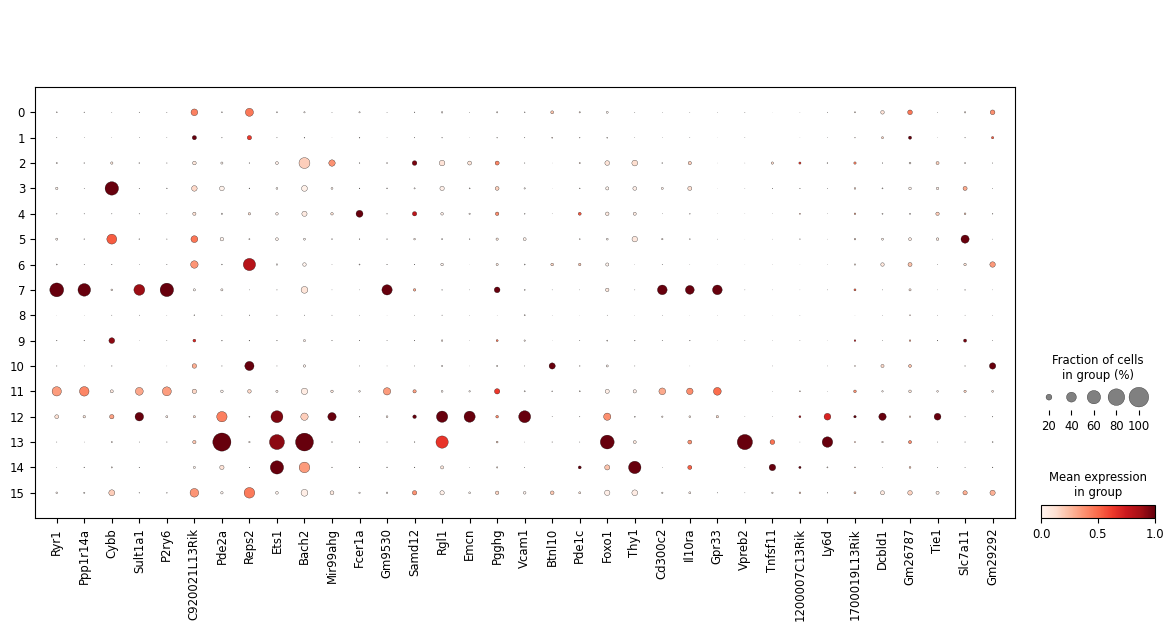

In [21]:
top_markers = []
for cl in interesting:
    genes = (
        markers[markers["group"] == cl]
        .sort_values("logfoldchanges", ascending=False)
        .head(5)["names"]
        .tolist()
    )
    top_markers.extend(genes)

top_markers = list(dict.fromkeys(top_markers))

sc.pl.dotplot(
    adata,
    var_names=top_markers,
    groupby="leiden_raw",
    standard_scale="var",
)

In [22]:
cluster_annotation = pd.DataFrame({
    "cluster": cluster_summary.index.astype(str),
    "dominant_pred": cluster_summary["dominant_pred"].astype(str),
    "mean_ood": cluster_summary["mean_ood"],
    "mean_conf": cluster_summary["mean_conf"],
    "dominant_time": cluster_summary["dominant_time"].astype(str),
})
cluster_annotation

,cluster,dominant_pred,mean_ood,mean_conf,dominant_time
leiden_raw,,,,,
15,15,15,0.918825,0.694145,D8
11,11,11,0.716321,0.836224,D14
9,9,9,0.702898,0.885578,D14
3,3,5,0.682884,0.657760,D21
4,4,4,0.657934,0.929777,D21
2,2,2,0.657437,0.862980,D14
10,10,10,0.609982,0.843786,D21
8,8,8,0.549889,0.929202,D8
5,5,5,0.548251,0.969304,D11


In [23]:
cluster_annotation["candidate_identity"] = ""

In [24]:
for cl in ["1", "2", "4", "6", "8", "12", "13", "14"]:
    print(f"\n=== Cluster {cl} ===")
    display(markers[markers["group"] == cl].head(20))


=== Cluster 1 ===


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
3000,1,mt-Nd1,83.019829,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3001,1,mt-Nd4,81.090172,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3002,1,mt-Nd2,80.606689,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3003,1,mt-Nd5,78.668961,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3004,1,mt-Co1,65.336746,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3005,1,Gm42418,60.702835,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3006,1,Malat1,59.140331,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3007,1,Gm26917,58.519814,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3008,1,Mt2,57.556442,NaN,0.000000e+00,0.000000e+00,1.0,1.0
3009,1,Nfkbia,53.906506,NaN,0.000000e+00,0.000000e+00,1.0,1.0



=== Cluster 2 ===


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
6000,2,Adgrl4,85.816238,NaN,0.0,0.0,1.0,1.0
6001,2,Cd34,85.140358,NaN,0.0,0.0,1.0,1.0
6002,2,Tmem176b,78.723267,NaN,0.0,0.0,1.0,1.0
6003,2,H2afy,76.293419,NaN,0.0,0.0,1.0,1.0
6004,2,Aff3,73.282257,NaN,0.0,0.0,1.0,1.0
6005,2,Sox4,72.247787,NaN,0.0,0.0,1.0,1.0
6006,2,Ctla2a,71.518150,NaN,0.0,0.0,1.0,1.0
6007,2,Gmfg,69.654198,NaN,0.0,0.0,1.0,1.0
6008,2,Fxyd5,69.400558,NaN,0.0,0.0,1.0,1.0
6009,2,Mef2c,67.006027,NaN,0.0,0.0,1.0,1.0



=== Cluster 4 ===


...

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
36000,12,Malat1,23.706093,NaN,3.119992e-124,3.119992e-121,1.0,1.0
36001,12,Gimap6,22.318232,NaN,2.458219e-110,1.843664e-107,1.0,1.0
36002,12,Fabp4,21.672766,NaN,3.707983e-104,1.853991e-101,1.0,1.0
36003,12,Stab2,20.513483,NaN,1.631796e-93,6.993413e-91,1.0,1.0
36004,12,Igfbp7,20.344400,NaN,5.204414e-92,1.951655e-89,1.0,1.0
36005,12,Sparc,20.272074,NaN,2.268912e-91,7.563040e-89,1.0,1.0
36006,12,Hivep3,19.731056,NaN,1.167051e-86,3.501153e-84,1.0,1.0
36007,12,Selenop,19.697390,NaN,2.270291e-86,6.191702e-84,1.0,1.0
36008,12,Galnt18,19.311270,NaN,4.318290e-83,9.965286e-81,1.0,1.0
36009,12,Abcc9,18.819853,NaN,5.192793e-79,1.038559e-76,1.0,1.0



=== Cluster 13 ===


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
39000,13,Ebf1,32.680874,NaN,2.920118e-234,8.760355e-231,1.0,1.0
39001,13,Blnk,31.357252,NaN,7.748694e-216,1.162304e-212,1.0,1.0
39002,13,Ighm,30.414669,NaN,3.514700e-203,3.514700e-200,1.0,1.0
39003,13,Vpreb1,30.399082,NaN,5.648596e-203,4.236447e-200,1.0,1.0
39004,13,Cd79a,30.090506,NaN,6.449928e-199,3.869957e-196,1.0,1.0
39005,13,Igll1,29.994072,NaN,1.172552e-197,5.862762e-195,1.0,1.0
39006,13,Pde2a,29.423937,NaN,2.713858e-190,1.163082e-187,1.0,1.0
39007,13,Cd79b,28.844049,NaN,6.017090e-183,2.256409e-180,1.0,1.0
39008,13,Mzb1,28.835161,NaN,7.777211e-183,2.592404e-180,1.0,1.0
39009,13,Lef1,28.069399,NaN,2.316169e-173,6.948506e-171,1.0,1.0



=== Cluster 14 ===


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
42000,14,Rora,25.873020,NaN,1.340388e-147,4.021163e-144,1.0,1.0
42001,14,Junb,25.587448,NaN,2.104514e-144,3.156771e-141,1.0,1.0
42002,14,Ltb,25.063871,NaN,1.232571e-138,1.232571e-135,1.0,1.0
42003,14,Skap1,23.565506,NaN,8.706348e-123,6.529761e-120,1.0,1.0
42004,14,H2-Q7,23.215414,NaN,3.181730e-119,1.909038e-116,1.0,1.0
42005,14,Emb,23.010706,NaN,3.642002e-117,1.821001e-114,1.0,1.0
42006,14,Id2,22.435705,NaN,1.764928e-111,7.563978e-109,1.0,1.0
42007,14,Btg1,22.391150,NaN,4.800480e-111,1.800180e-108,1.0,1.0
42008,14,Bhlhe40,22.294472,NaN,4.180759e-110,1.393586e-107,1.0,1.0
42009,14,Tnfaip3,22.246195,NaN,1.227761e-109,3.683283e-107,1.0,1.0


# Mannual annotation with marker genes clusterwise

In [25]:
cluster_labels = {
    "0":  "stable erythroid",
    "1":  "stressed erythroid-like",
    "2":  "HSC / primitive progenitor-like",
    "3":  "granulocytic / emergency myeloid",
    "4":  "HSC / megakaryocyte-primed progenitor-like",
    "5":  "stable erythroid-like",
    "6":  "erythroid progenitor-like",
    "7":  "stable APC-like",
    "8":  "stress-associated / ambiguous",
    "9":  "stressed myeloid-like",
    "10": "transitional erythroid",
    "11": "activated APC-like",
    "12": "macrophage-like / remodeling myeloid",
    "13": "B-lineage / pre-B-like",
    "14": "T/NK-like lymphoid",
    "15": "divergent erythroid-like",
}

In [26]:
adata.obs["cluster_label_mannual"] = adata.obs["leiden_raw"].astype(str).map(cluster_labels)

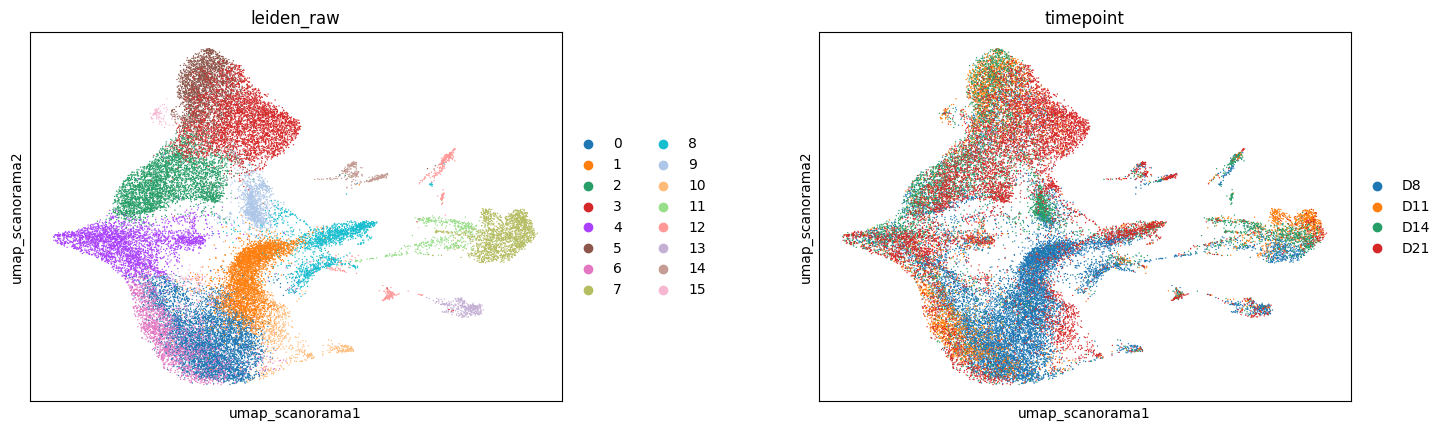

In [27]:
sc.pl.embedding(
    adata,
    basis="umap_scanorama",
    color=["leiden_raw",  "timepoint"],
    wspace=0.35,
)

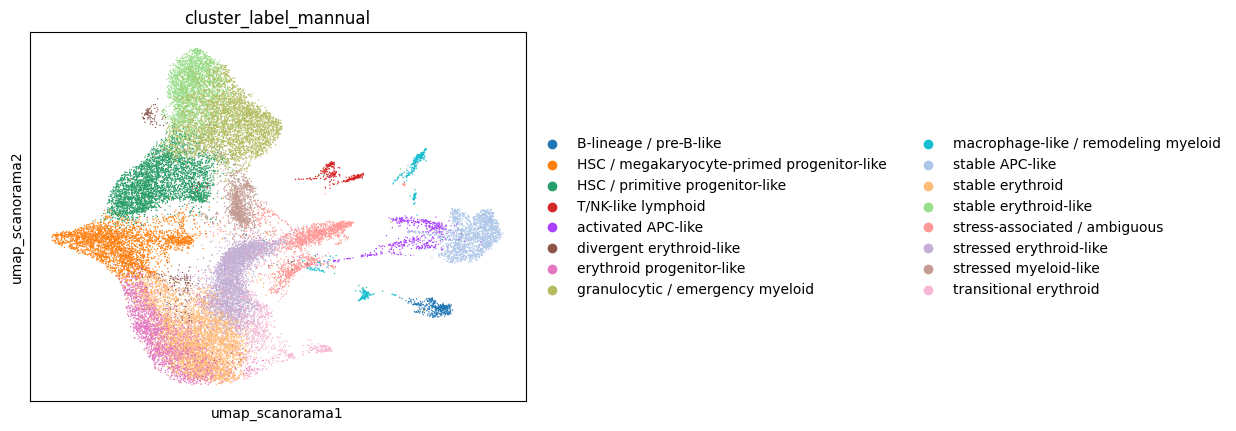

In [28]:
sc.pl.embedding(
    adata,
    basis="umap_scanorama",
    color="cluster_label_mannual",
    wspace=0.35,
)

In [29]:
adata.obs.groupby("cluster_label_mannual")[["scgeo_conf", "scgeo_ood"]].mean().sort_values("scgeo_ood", ascending=False)

/tmp/ipykernel_6216/3390450004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("cluster_label_mannual")[["scgeo_conf", "scgeo_ood"]].mean().sort_values("scgeo_ood", ascending=False)


,scgeo_conf,scgeo_ood
cluster_label_mannual,,
divergent erythroid-like,0.694145,0.918825
activated APC-like,0.836224,0.716321
stressed myeloid-like,0.885578,0.702898
granulocytic / emergency myeloid,0.657760,0.682884
HSC / megakaryocyte-primed progenitor-like,0.929777,0.657934
HSC / primitive progenitor-like,0.862980,0.657437
transitional erythroid,0.843786,0.609982
stress-associated / ambiguous,0.929202,0.549889
stable erythroid-like,0.969304,0.548251


In [30]:
pd.crosstab(
    adata.obs["cluster_label_mannual"],
    adata.obs["alignment_group"],
    normalize="index",
)

alignment_group,aligned,discordant,other
cluster_label_mannual,,,
B-lineage / pre-B-like,0.0,1.0,0.0
HSC / megakaryocyte-primed progenitor-like,0.0,1.0,0.0
HSC / primitive progenitor-like,1.0,0.0,0.0
T/NK-like lymphoid,1.0,0.0,0.0
activated APC-like,0.0,1.0,0.0
divergent erythroid-like,0.0,1.0,0.0
erythroid progenitor-like,0.0,0.0,1.0
granulocytic / emergency myeloid,1.0,0.0,0.0
macrophage-like / remodeling myeloid,0.0,1.0,0.0


In [31]:
cluster_summary.to_csv("data/GSE280305_cluster_summary.tsv", sep="\t")
pd.DataFrame(
    {"cluster": list(cluster_labels.keys()), "label": list(cluster_labels.values())}
).to_csv("data/GSE280305_cluster_labels.tsv", sep="\t", index=False)

In [32]:
adata.write("data/GSE280305_for_Ref.h5ad")